# Density-split examples

This notebook shows a minimal tree-level density-split multipoles prediction in **desilike**.
The linear power spectrum is provided by the native DESI fiducial template.

## Theory prediction

The calculator returns an array with shape `(n_quantiles, n_ells, n_k)`.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from desilike.theories.galaxy_clustering import DensitySplitTracerPowerSpectrumMultipoles, FixedPowerSpectrumTemplate

In [2]:
z = 1.0
k = np.linspace(0.01, 0.2, 100)
ells = (0, 2, 4)
quantiles = (1, 2, 3, 4, 5)

template = FixedPowerSpectrumTemplate(z=z, fiducial='DESI')
theory = DensitySplitTracerPowerSpectrumMultipoles(k=k, ells=ells, quantiles=quantiles, template=template, smoothing_radius=10.)

power = np.asarray(theory())
power.shape

(5, 3, 100)

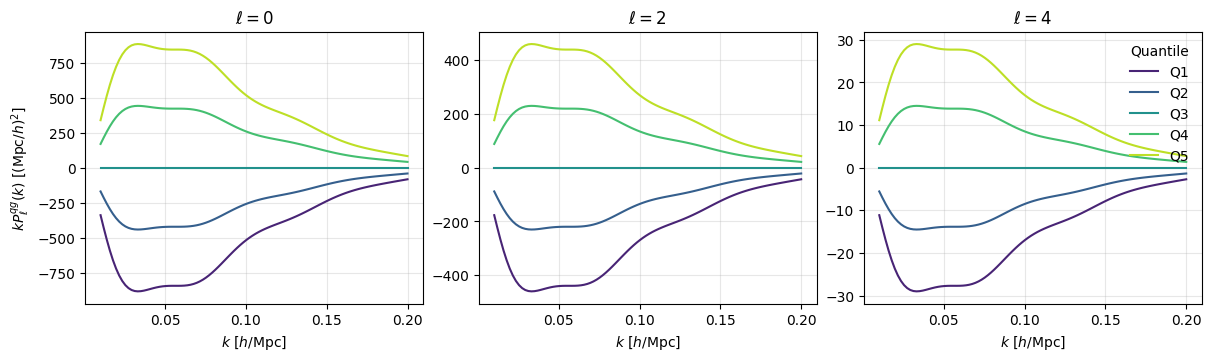

In [3]:
fig, axes = plt.subplots(1, len(ells), figsize=(12, 3.5), sharex=True, constrained_layout=True)
colors = plt.get_cmap('viridis')(np.linspace(0.1, 0.9, len(quantiles)))

for ill, (ell, ax) in enumerate(zip(ells, axes)):
    for iq, (quantile, color) in enumerate(zip(quantiles, colors)):
        ax.plot(k, k * power[iq, ill], color=color, label='Q{:d}'.format(quantile))
    ax.set_title(r'$\ell = {:d}$'.format(ell))
    ax.set_xlabel(r'$k$ [$h / \mathrm{Mpc}$]')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r'$k P^{qg}_{\ell}(k)$ [$(\mathrm{Mpc}/h)^2$]')
axes[-1].legend(title='Quantile', frameon=False)
plt.show()

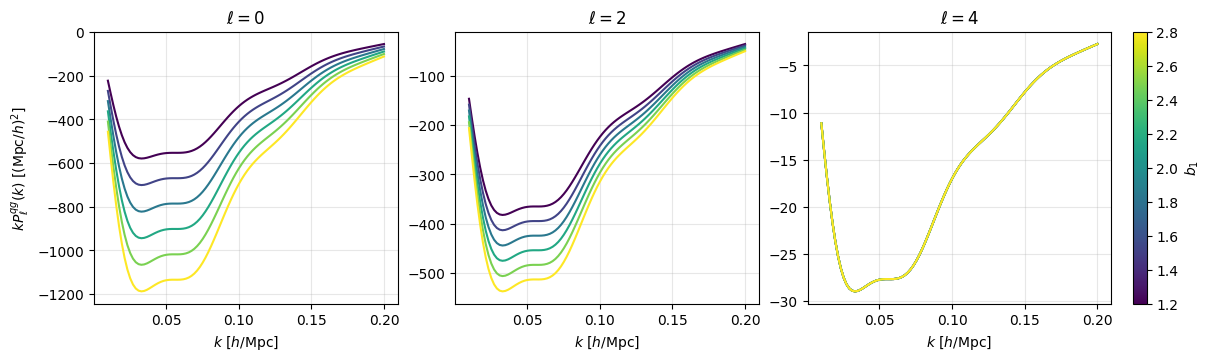

In [4]:
quantile = 1
quantile_index = quantiles.index(quantile)
b1_values = np.linspace(1.2, 2.8, 6)

cmap = plt.get_cmap('viridis')
norm = plt.Normalize(b1_values.min(), b1_values.max())
fig, axes = plt.subplots(1, len(ells), figsize=(12, 3.5), sharex=True, constrained_layout=True)

for b1 in b1_values:
    power_b1 = np.asarray(theory(b1=b1))
    color = cmap(norm(b1))
    for ill, (ell, ax) in enumerate(zip(ells, axes)):
        ax.plot(k, k * power_b1[quantile_index, ill], color=color)
        ax.set_title(r'$\ell = {:d}$'.format(ell))
        ax.set_xlabel(r'$k$ [$h / \mathrm{Mpc}$]')
        ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r'$k P^{qg}_\ell(k)$ [$(\mathrm{Mpc}/h)^2$]')
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])
colorbar = fig.colorbar(mappable, ax=axes, pad=0.02)
colorbar.set_label(r'$b_1$')
plt.show()